# Pore Network Model Drainage Simulation

__Author(s):__ Masa Prodanovic

__Last Update:__ Sep. 2025

Copyright © 2025 Digital Porous Media Team. All rights reserved.

---


__Download Finney sphere pack image from Digital Rocks Portal__

In [ ]:
file_url = "https://www.digitalrocksportal.org/projects/47/images/73328/download/"
filename = "spheres_a10_dx0.04_n500_segmented_unsigned_char.raw"


import requests # library for file download
r = requests.get(file_url, stream = True) 
  
with open(filename,"wb") as f: 
    for chunk in r.iter_content(chunk_size=1024): 
  
         # writing one chunk at a time to pdf file 
         if chunk: 
             f.write(chunk)

                

Read the data into a 3D array.

In [2]:
import numpy as np

# the file is binary (.raw) file, and requires information from the webpage on how to read it.
width  = 500
height = 500
slices = 500

dtype  = 'u1' #8-bit data (unsigned)
byte = '<'  # little endian byte order

filename = "spheres_a10_dx0.04_n500_segmented_unsigned_char.raw"
# read data from file
datatype = byte + dtype    
alldata = np.fromfile(filename, dtype=datatype, sep="")
im = alldata.reshape([slices, height, width])

ValueError: cannot reshape array of size 224966 into shape (500,500,500)

In [64]:
print('Image shape')
print(im.shape)

Image shape
(500, 500, 500)


Imports for PoreSpy
Following: https://github.com/PMEAL/OpenPNM/blob/dev/examples/notebooks/networks/extraction/predicting_effective_permeability_of_berea.ipynb

In [65]:
import os
import imageio
import scipy as sp
import numpy as np
import openpnm as op
import porespy as ps
import matplotlib.pyplot as plt
np.set_printoptions(precision=4)
np.random.seed(10)
%matplotlib inline

Porosity
0.638168064


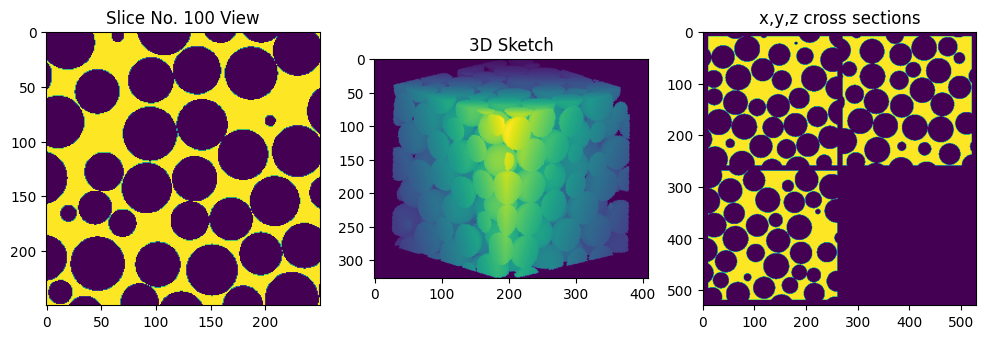

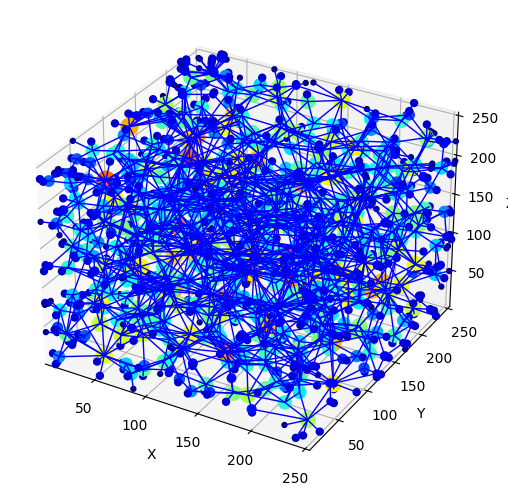

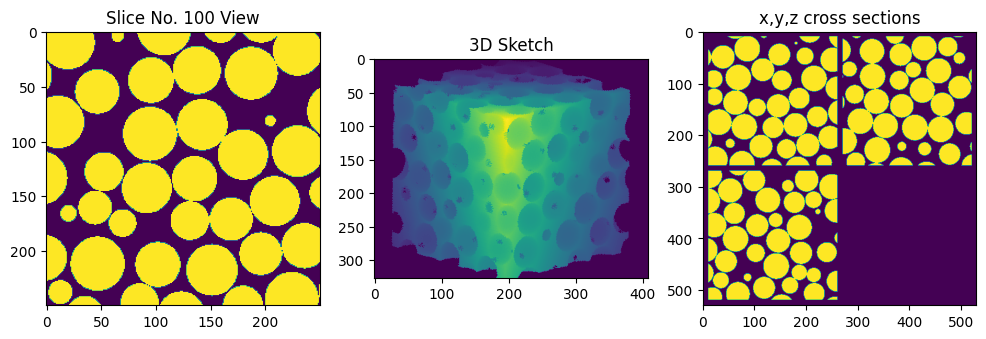

In [70]:
# Make image smaller (250 cube)
# ~ inverts phases which is necessary in this case, but that depends on how solids and pores are labeled in the original
# Porosity below value will tell you if you got the phases right.
im = ~np.array(im, dtype=bool)[:250, :250, :250]

#do not make anything smaller
#im = ~np.array(im, dtype=bool)

print('Porosity')
print(ps.metrics.porosity(im))

#Plot image
fig, ax = plt.subplots(1, 3, figsize=(12,5))
ax[0].imshow(im[:, :, 100]);
ax[1].imshow(ps.visualization.show_3D(im));
ax[2].imshow(ps.visualization.show_planes(im))
#ax[2].imshow(ps.visualization.sem(im));
ax[0].set_title("Slice No. 100 View");
ax[1].set_title("3D Sketch");
ax[2].set_title("x,y,z cross sections");
plt.show()

In [67]:
# snow object will have network results
dx = 1.0  # voxel_size
snow = ps.networks.snow2(im, voxel_size=dx)

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

Extracting pore and throat properties:   0%|          | 0/1205 [00:00<?, ?it/s]

In [68]:
#pn, geo = op.io.PoreSpy.import_data(snow.network)
pn = op.io.network_from_porespy(snow.network)
print(pn)


══════════════════════════════════════════════════════════════════════════════
net : <openpnm.network.Network at 0x21686aaca00>
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  #  Properties                                                   Valid Values
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  2  throat.conns                                                  2718 / 2718
  3  pore.coords                                                   1205 / 1205
  4  pore.region_label                                             1205 / 1205
  5  pore.phase                                                    1205 / 1205
  6  throat.phases                                                 2718 / 2718
  7  pore.region_volume                                            1205 / 1205
  8  pore.equivalent_diameter                                      1205 / 1205
  9  pore.local_peak                                               1205 / 1205
 1

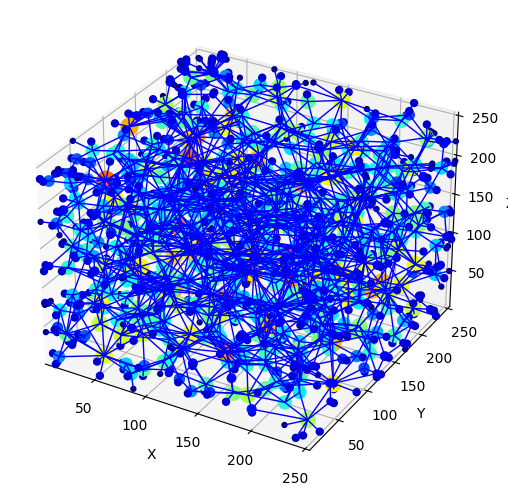

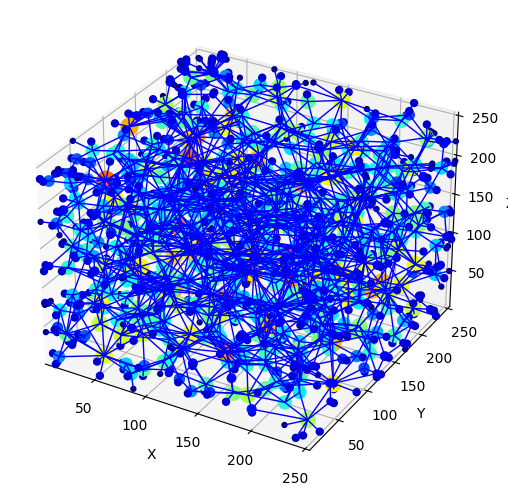

In [72]:
fig, ax = plt.subplots(figsize=[5, 5])
op.visualization.plot_coordinates(ax=fig,
                                  network=pn,
                                  size_by=pn["pore.inscribed_diameter"],
                                  color_by=pn["pore.inscribed_diameter"],
                                  markersize=200)
op.visualization.plot_connections(network=pn, ax=fig)
plt.show()

In [10]:
# output a file that can be visualized in ParaView
op.io.project_to_vtk(project=pn.project)

# this enables overlay of the network and pore/grain surface in 
im = ps.tools.align_image_with_openpnm(im)
imageio.volsave('image.tif', np.array(im, dtype=np.int8))

In [73]:
#reg = ps.networks.map_to_regions(regions=snow.regions, values=pn['pore.region_label'])

# Why does this work better for visualization than the above options? That said, \
# I am not happy with snow2 result.
pn['pore.values'] = np.random.rand(pn.Np)
reg = ps.networks.map_to_regions(regions=snow.regions, values=pn['pore.values'])

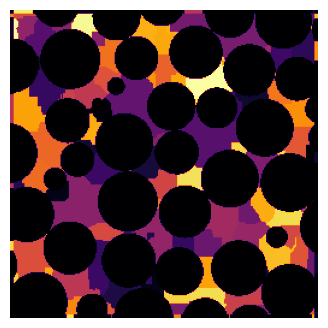

In [74]:
fig = plt.figure(figsize=[4, 4])
plt.imshow(reg[:,:,100], origin='lower',cmap = 'inferno')
plt.axis('off');
plt.show()

In [24]:
help(ps.networks.snow2)

Help on function snow2 in module porespy.networks._snow2:

snow2(phases, phase_alias=None, boundary_width=3, accuracy='standard', voxel_size=1, sigma=0.4, r_max=4, peaks=None, parallelization={})
    Applies the SNOW algorithm to each phase indicated in ``phases``.

    This function is a combination of ``snow`` [1]_, ``snow_dual`` [2]_,
    ``snow_n`` [3]_, and ``snow_parallel`` [4]_ from previous versions.

    Parameters
    ----------
    phases : ndarray
        An image indicating the phase(s) of interest. A watershed is
        produced for each integer value in ``phases`` (except 0's). These
        are then combined into a single image and one network is extracted
        using ``regions_to_network``.
    phase_alias : dict
        A mapping between integer values in ``phases`` and phase name
        used to add labels to the network. For instance, asssuming a
        two-phase image, ``{1: 'void', 2: 'solid'}`` will result in the
        labels ``'pore.void'`` and ``'pore.sol

__Find permeability of this network__ 

We're following https://openpnm.org/examples/applications/network_extraction.html

In [19]:
# Check that the network is topologically sound.
h = op.utils.check_network_health(pn)
print(h)

op.topotools.trim(network=pn, pores=h['disconnected_pores'])
h = op.utils.check_network_health(pn)
print(h)

――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
Key                                 Value
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
headless_throats                    []
looped_throats                      []
isolated_pores                      []
disconnected_pores                  []
duplicate_throats                   []
bidirectional_throats               []
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
Key                                 Value
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
headless_throats                    []
looped_throats                      []
isolated_pores                      []
disconnected_pores                  []
duplicate_throats                   []
bidirectional_throats               []
―――――――――――――――――――――――――――――――――――――――――――――――――――――

In [48]:
# Make a choice for pore and throat diameters (we could use inscribed or equivalent) and geometry (hydraulic conductance calculation).

pn['pore.diameter'] = pn['pore.equivalent_diameter']
pn['throat.diameter'] = pn['throat.inscribed_diameter']
pn['throat.spacing'] = pn['throat.total_length']

# This is one of the choices for geometrical model for pores (spheres) and
# throast (cylinders). Note that sphere model for pore will have correct volume
# since we set the pore diameter to equivalent diameter.
pn.add_model_collection(op.models.collections.geometry.spheres_and_cylinders)
pn.regenerate_models()

pn.add_model(propname='throat.hydraulic_size_factors',
             model=op.models.geometry.hydraulic_size_factors.spheres_and_cylinders)
pn.add_model(propname='throat.diffusive_size_factors',
             model=op.models.geometry.diffusive_size_factors.spheres_and_cylinders)
pn.regenerate_models()

In [49]:
# Set the fluid phase properties, viscosity is the main relevant one here.

water = op.phase.Phase(network=pn)

water['pore.viscosity'] = 1.0
water.add_model_collection(op.models.collections.physics.basic)
water.regenerate_models()

# This would be the way to add a built in viscosity model.
#water.add_model(propname='pore.viscosity',model=op.models.phase.viscosity.water_correlation)
#print(water)


[14:06:35] WARNING  throat.entry_pressure was not run since the following property is missing:       ]8;id=662943;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\core\_models.py\_models.py]8;;\:]8;id=851597;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\core\_models.py#480\480]8;;\
                    'throat.surface_tension'                                                                       

           WARNING  throat.diffusive_conductance was not run since the following property is         ]8;id=149550;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\core\_models.py\_models.py]8;;\:]8;id=616736;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\core\_models.py#480\480]8;;\
                    missing: 'throat.diffusivity'                                                                  

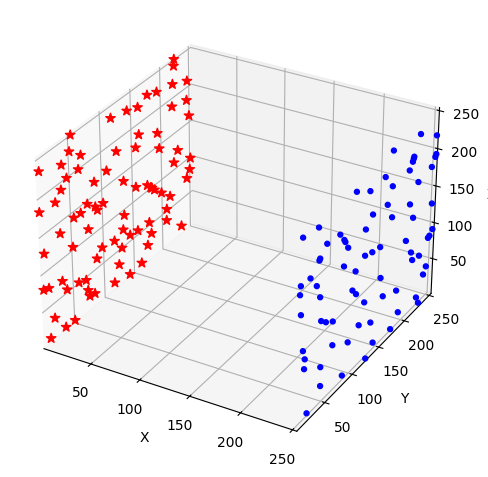

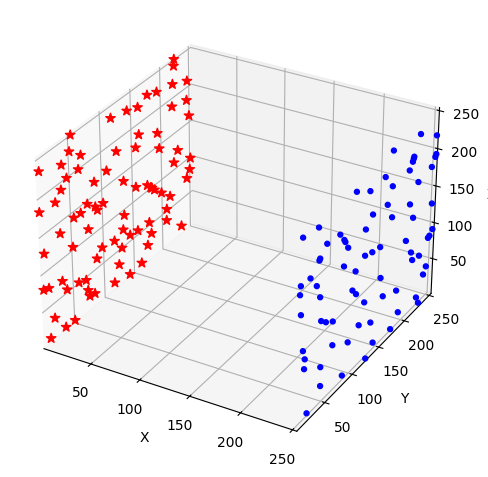

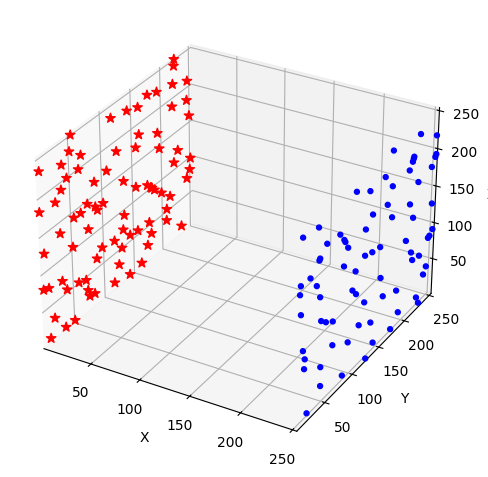

In [77]:
# Identify inlets and outlets
fig, ax = plt.subplots()
inlet = pn.pores('xmin')
outlet = pn.pores('xmax')

op.visualization.plot_coordinates(pn, inlet, c='red', marker='*', 
                                  markersize=50, ax=ax)
op.visualization.plot_coordinates(pn, outlet, c='blue', marker='.', 
                                  markersize=50, ax=ax);
plt.show()


In [78]:
sf = op.algorithms.StokesFlow(network=pn, phase=water)

dP = 1.0  # pressure difference
sf.set_value_BC(pores = inlet, values=0.0+dP)
sf.set_value_BC(pores = outlet, values=0.0)
sf.run()

# recall that the scaling for voxel length was used at the beginning and is called dx

# 3D dimensions of the array
nz,ny,nx = np.shape(im)

L = (nx + 6)*dx # I think 6 has to be added for inlet/outlet addition of pores
A = ny*nz*dx**2
# viscosity is assumed to be set to 1.
K = sf.rate(pores=pn.pores('xmin'))*(L/A)/dP
print(f'Permeability coefficient is {K[0]} in lattice units (assuming voxel length is 1.0)')


KeyError: 'phase_09'

__Drainage process__

In [61]:
air = op.phase.Air(network=pn)

# air is non-wetting and is displacing water which is wetting
air['pore.contact_angle'] = 120
air['pore.surface_tension'] = 0.072

# model for setting the throat entry pressure
f = op.models.physics.capillary_pressure.washburn

air.add_model(propname='throat.entry_pressure',
              model=f, 
              surface_tension='throat.surface_tension',
              contact_angle='throat.contact_angle',
              diameter='throat.diameter')

drn = op.algorithms.Drainage(network=pn, phase=air)
drn.set_inlet_BC(pores=inlet)
drn.run()

print(drn)


Performing drainage simulation:   0%|          | 0/25 [00:00<?, ?it/s]


══════════════════════════════════════════════════════════════════════════════
drainage_09 : <openpnm.algorithms.Drainage at 0x21686aae620>
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  #  Properties                                                   Valid Values
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  2  pore.invasion_pressure                                        1205 / 1205
  3  throat.invasion_pressure                                      2718 / 2718
  4  pore.invasion_sequence                                        1205 / 1205
  5  throat.invasion_sequence                                      2718 / 2718
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  #  Labels                                                 Assigned Locations
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  2  pore.all                                                        

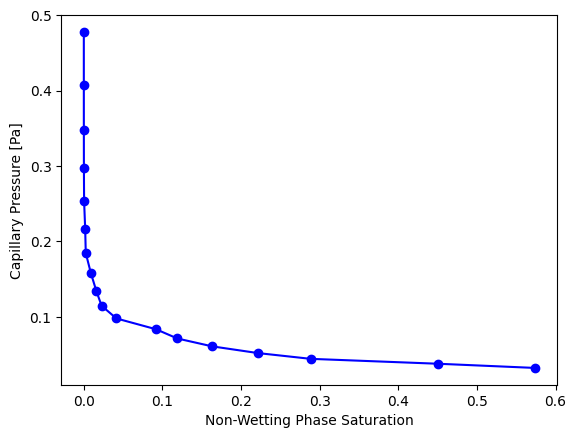

In [62]:
plt.figure()
# no trapping is applied here
data = drn.pc_curve()
plt.plot(1-data.snwp,data.pc, 'b-o')
plt.ylabel('Capillary Pressure [Pa]')
plt.xlabel('Wetting Phase Saturation');
plt.show()